# STAT 207 Homework 8 [25 points]

## Linear Model Assumptions & Logistic Models

Due: Monday, April 6, end of day (11:59 pm CT)

Late submissions accepted until Tuesday, April 7 at noon

<hr>

## Research Question:

For this homework assignment, our first research question of interest is: "Can we accurately predict how long a hospital stay will be for seriously ill patients from its linear relationship with selected other variables in the data?"

---

Our second research question of interest is: "Can we learn about the relationship between level of care required and variables including the age, sex, and comorbidity of the patient?"

## Case Study

A famous study called "SUPPORT" (Study to Understand Prognoses Preferences Outcomes and Risks of Treatment) was conducted to determine what factors affected or predicted outcomes, including how long a patient remained in the hospital.

We will use a random sample of 580 seriously ill hospitalized patients from the SUPPORT study, with the following variables:

- **`Days`**: day to death or hospital discharge
- **`Age`**: age on day of hospital admission
- **`Sex`**: female or male
- **`Comorboidity`**: patient diagnosed with one or more chronic disease
- **`EdYears`**: years of education
- **`Education`**: education level: high or low
- **`Income`**: income level: high or low
- **`Charges`**: hospital charges, in dollars
- **`Care`**: level of care required: high or low
- **`Race`**: Non-white or white
- **`Pressure`**: Blood pressure, in mmHg
- **`Blood`**: white blood cell count, in gm/dL
- **`Rate`**: heart rate, in bpm

## 1. Imports [1 point]

**a)**  Import the packages needed for this assignment:

- pandas
- matplotlib.pyplot
- seaborn
- sklearn for creating training and test data
- statsmodels for fitting a linear model

The first package assists in analyzing a dataset.  The second two packages provide support for visualizations.  The fourth package will be used for splitting the data into a training and a test data.  The last package will be used for fitting a linear model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set()
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
import statsmodels.graphics.gofplots as sm 


**b)** Run the following lines of code to read in the data and create your training and testing data.

In [3]:
df = pd.read_csv('hospital.csv')
df_train, df_test = train_test_split(df, test_size = 0.15, random_state = 674)

**c)** I'd suggest turning to Q1 on Gradescope here.  

I don't anticipate a need to perform any more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like.

In [4]:
df_train

,Days,Age,Sex,Comorbidity,EdYears,Education,Income,Charges,Care,Race,Pressure,Blood,Rate
134,4,55.482971,male,yes,12,low,high,15966.00000,low,white,97,6.099609,64
53,11,45.310974,male,yes,12,low,high,32838.00000,low,white,125,7.899414,74
8,9,77.094971,male,yes,16,high,high,23862.00000,low,white,93,11.599609,86
411,12,61.929993,male,yes,6,low,low,20880.00000,high,white,117,9.599609,133
473,12,61.653992,male,no,12,low,high,39699.00000,high,non-white,162,10.298828,113
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,11,65.844971,male,yes,8,low,high,36142.50000,high,white,56,7.500000,96
409,32,76.963989,female,yes,14,high,high,122608.00000,high,white,65,21.898438,62
79,31,60.544983,male,yes,16,high,high,239928.00000,high,white,65,15.000000,125
541,6,50.189972,male,yes,12,low,high,3883.00000,low,white,77,10.398438,70


In [5]:
df_test

,Days,Age,Sex,Comorbidity,EdYears,Education,Income,Charges,Care,Race,Pressure,Blood,Rate
184,18,74.841980,female,yes,8,low,low,72912.250000,high,white,85,14.199219,60
461,5,69.540955,male,yes,6,low,low,8421.000000,high,non-white,100,7.500000,118
84,27,51.460999,female,yes,8,low,low,30321.000000,low,white,73,8.578125,140
43,6,44.024994,male,yes,12,low,low,35099.000000,high,white,75,11.199219,100
502,11,33.965973,male,yes,12,low,low,34737.000000,low,white,101,13.699219,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,8,71.128967,female,yes,13,high,high,57493.000000,low,white,98,17.097656,135
46,15,48.470978,female,yes,17,high,low,41422.000000,low,white,69,12.798828,112
391,4,62.452972,male,yes,11,low,low,3041.000000,low,non-white,106,6.699219,126
202,7,64.996948,male,yes,10,low,high,7358.796875,low,white,100,6.099609,78


## 2. Linear Model of Interest [2.5 points]

**a)** Run the code to fit a linear model to the training data predicting the number of days of the hospital stay based on the age, years of education, white blood count, race, and the interaction of the race with the years of education. 

In [6]:
results = smf.ols('Days ~ Age + EdYears + Blood + Race + Race * EdYears', data = df_train).fit()

**b)** Create a fitted vs. residuals plot for this model.

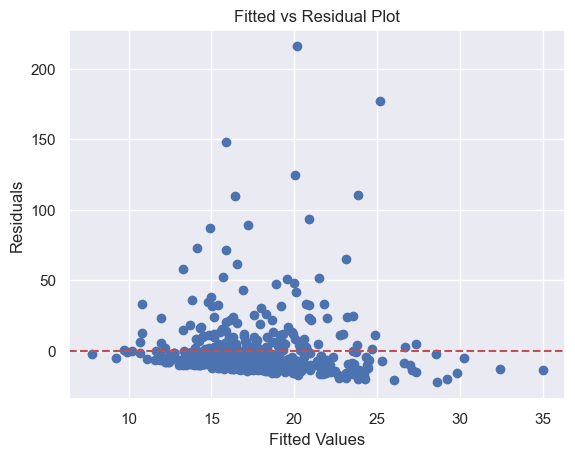

In [11]:
plt.scatter(x= results.predict(df_train), y = results.resid)
plt.axhline(y = 0, color = "r", linestyle = "--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual Plot")
plt.show()

**c)** Generate an appropriate QQ plot for this model.

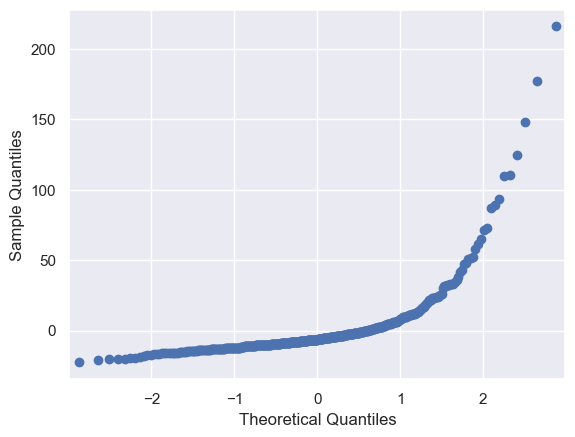

In [13]:
sm.qqplot(results.resid)
plt.show()

**d)** I'd suggest turning to Q2 on Gradescope here.  

I don't anticipate a need to perform any more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like.

## 3. Displaying the Linear Model [0.5 points]

**a)** Display a summary of the linear model that you fit in Question 2.

In [14]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Days   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.454
Date:                Wed, 08 Apr 2026   Prob (F-statistic):             0.0327
Time:                        16:28:54   Log-Likelihood:                -2245.2
No. Observations:                 493   AIC:                             4502.
Df Residuals:                     487   BIC:                             4528.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                18.4304      8.940      2.062      0.040       0.865      35.996
Race[T.white]             3.1126      8.323      0.374      0.709     -13.241      19.466
Age                      -0.1221      0.067     -1.817      0.070      -0.254       0.010
EdYears                  -0.0306      0.615     -0.050      0.960      -1.239       1.178
Race[T.white]:EdYears -3.989e-05      0.691  -5.77e-05      1.000      -1.358       1.358
Blood                     0.3754      0.132      2.844      0.005       0.116       0.635
==============================================================================
Omnibus:                      507.119   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            20010.929
Skew:                           4.681   Prob(JB):                         0.00
Kurtosis:                      32.775   Cond. No.                         728.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**b)** I'd suggest turning to Q3 on Gradescope here.  

You may need to perform more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like, although there are no points associated with this part.

## 4. A Second Model [1.5 point]

**a)** For this last question, we will respond to the second research question for this assignment, which is: "Can we learn about the relationship between level of care required and variables including the age, sex, and comorbidity of the patient?"

Fit a logistic model to the training data predicting the level of care required from the age, sex, and comorbidities of the patient.  For this model, define a success as needing a high level of care.

In [16]:
df_train["HighCare"] = (df_train["Care"] == "high").astype(int)
results2 = smf.logit("HighCare ~ Age + Sex + Comorbidity", data = df_train).fit()
results2.summary()

Optimization terminated successfully.
         Current function value: 0.645326
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               HighCare   No. Observations:                  493
Model:                          Logit   Df Residuals:                      489
Method:                           MLE   Df Model:                            3
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.06697
Time:                        16:33:10   Log-Likelihood:                -318.15
converged:                       True   LL-Null:                       -340.98
Covariance Type:            nonrobust   LLR p-value:                 6.658e-10
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.8076      0.515      5.449      0.000       1.798       3.817
Sex[T.male]           -0.2900      0.190     -1.525      0.127      -0.663       0.083
Comorbidity[T.yes]    -1.6464      0.354     -4.656      0.000      -2.340      -0.953
Age                   -0.0208      0.006     -3.421      0.001      -0.033      -0.009
======================================================================================
"""

**b)** I'd suggest turning to Q4 on Gradescope here.  

You may need to perform more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like, although there are no points associated with this part.

## 5. AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class (intended only for projects).  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

no

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use (including links, if appropriate)?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 8 Canvas Assignment to submit your notebook to GitHub.